In [213]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.measure import label, regionprops
from skimage.morphology import skeletonize

(np.float64(-0.5), np.float64(447.5), np.float64(447.5), np.float64(-0.5))

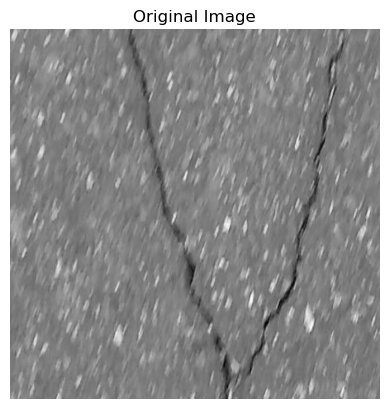

In [214]:
img = cv2.imread(r"D:\CPV ti len tt\images\CRACK500_20160330_163725_641_721.jpg", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

(np.float64(-0.5), np.float64(447.5), np.float64(447.5), np.float64(-0.5))

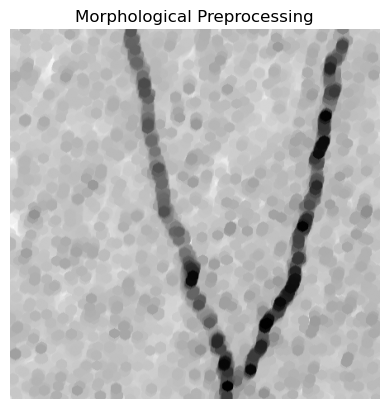

In [215]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

radius = 3
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(2*radius+1,2*radius+1))

# erosion
eroded = cv2.erode(img, kernel)

# opening
opened = cv2.morphologyEx(eroded, cv2.MORPH_OPEN, kernel)

# final erosion
smoothed = cv2.erode(opened, kernel)

plt.imshow(smoothed, cmap='gray')
plt.title("Morphological Preprocessing")
plt.axis("off")

## Methodology Demonstration: Preprocessing Comparison
Here we compare three preprocessing methods:
1. **Anisotropic Diffusion** (Total Variation)
2. **Wavelet Denoise**
3. **Morphological** (Closing/Opening sequence)

In [ ]:
import time
from skimage.restoration import denoise_tv_chambolle, denoise_wavelet

random.seed(42)
if len(image_paths) > 0:
    demo_img_path = random.choice(image_paths)
    demo_img = cv2.imread(demo_img_path, cv2.IMREAD_GRAYSCALE)
    
    # 1. Anisotropic Diffusion (Total Variation as edge-preserving smooth)
    t0 = time.time()
    img_float = demo_img.astype(float) / 255.0
    aniso = denoise_tv_chambolle(img_float, weight=0.1)
    aniso = (aniso * 255).astype(np.uint8)
    t_aniso = time.time() - t0
    
    # 2. Wavelet Denoise
    t0 = time.time()
    wavelet = denoise_wavelet(img_float, method='BayesShrink', mode='soft', rescale_sigma=True)
    wavelet = (wavelet * 255).astype(np.uint8)
    t_wavelet = time.time() - t0
    
    # 3. Morphological
    t0 = time.time()
    radius = 3
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*radius+1, 2*radius+1))
    eroded = cv2.erode(demo_img, kernel)
    opened = cv2.morphologyEx(eroded, cv2.MORPH_OPEN, kernel)
    morph = cv2.erode(opened, kernel)
    t_morph = time.time() - t0
    
    # Visualization
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    axes[0].imshow(demo_img, cmap='gray')
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    
    axes[1].imshow(aniso, cmap='gray')
    axes[1].set_title(f"Anisotropic Diff.\n({t_aniso:.4f}s)")
    axes[1].axis("off")
    
    axes[2].imshow(wavelet, cmap='gray')
    axes[2].set_title(f"Wavelet Denoise\n({t_wavelet:.4f}s)")
    axes[2].axis("off")
    
    axes[3].imshow(morph, cmap='gray')
    axes[3].set_title(f"Morphological\n({t_morph:.4f}s)")
    axes[3].axis("off")
    
    plt.suptitle("Comparison of Pre-processing Methods", fontsize=16)
    plt.tight_layout()
    plt.show()

(np.float64(-0.5), np.float64(447.5), np.float64(447.5), np.float64(-0.5))

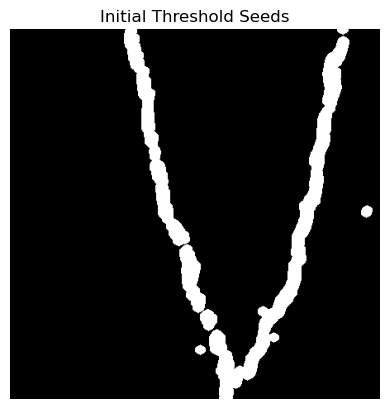

In [216]:
mu = np.mean(smoothed)
sigma = np.std(smoothed)

T = mu - 1 * sigma

seeds = smoothed < T

plt.imshow(seeds, cmap="gray")
plt.title("Initial Threshold Seeds")
plt.axis("off")

(np.float64(-0.5), np.float64(447.5), np.float64(447.5), np.float64(-0.5))

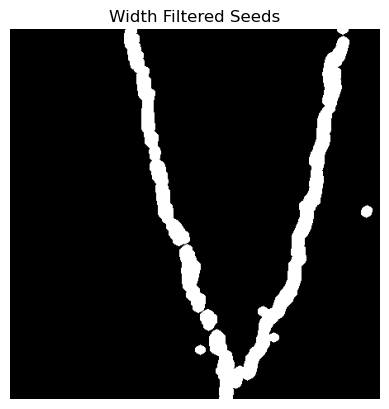

In [217]:
labels = label(seeds)

filtered = np.zeros_like(seeds)

for region in regionprops(labels):

    minr, minc, maxr, maxc = region.bbox
    width = min(maxr-minr, maxc-minc)

    if width >= 2:   # parameter w
        filtered[labels == region.label] = 1

plt.imshow(filtered, cmap="gray")
plt.title("Width Filtered Seeds")
plt.axis("off")

(np.float64(-0.5), np.float64(447.5), np.float64(447.5), np.float64(-0.5))

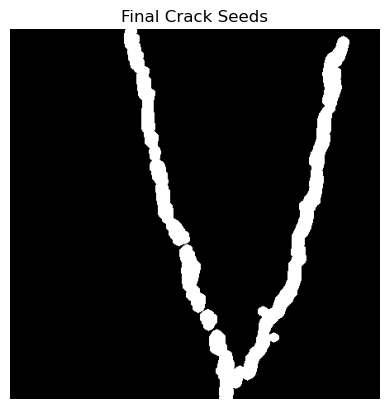

In [218]:
labels = label(filtered)

seeds_final = np.zeros_like(filtered)

for region in regionprops(labels):

    if region.major_axis_length >= 25:   # parameter lg
        seeds_final[labels == region.label] = 1

plt.imshow(seeds_final, cmap="gray")
plt.title("Final Crack Seeds")
plt.axis("off")

In [219]:
mask = seeds_final.copy()

kernel = np.ones((3,3), np.uint8)

for i in range(50):

    crack_pixels = smoothed[mask == 1]
    non_pixels = smoothed[mask == 0]

    mu_c = np.mean(crack_pixels)
    std_c = np.std(crack_pixels)

    mu_n = np.mean(non_pixels)
    std_n = np.std(non_pixels)

    z_crack = (smoothed - mu_c) / (std_c + 1e-8)
    z_non = (smoothed - mu_n) / (std_n + 1e-8)

    neighbors = cv2.dilate(mask.astype(np.uint8), kernel).astype(bool)

    candidate = (
        neighbors &
        (mask == 0) &
        (np.abs(z_non) > 1.96) &
        (np.abs(z_crack) < 1.96)
    )

    prev_pixels = np.sum(mask)

    mask[candidate] = 1

    new_pixels = np.sum(mask)

    Rc = (new_pixels - prev_pixels) / (prev_pixels + 1e-8)

    print("Iteration", i, "Rc =", Rc)

    if Rc < 0.005:
        break

Iteration 0 Rc = 0.08023929937086453
Iteration 1 Rc = 0.04025121324576634
Iteration 2 Rc = 0.01663007683862973
Iteration 3 Rc = 0.01031150461587739
Iteration 4 Rc = 0.008122261408566783
Iteration 5 Rc = 0.006466659599275698
Iteration 6 Rc = 0.00631978091425831
Iteration 7 Rc = 0.006175423906214059
Iteration 8 Rc = 0.004785186726305636


(np.float64(-0.5), np.float64(447.5), np.float64(447.5), np.float64(-0.5))

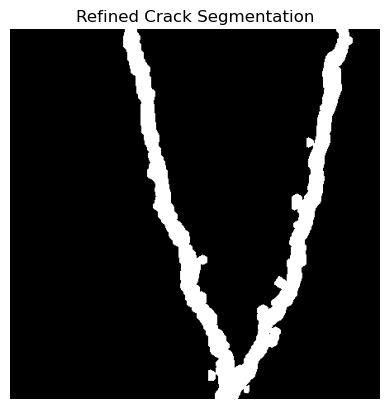

In [220]:
plt.imshow(mask, cmap="gray")
plt.title("Refined Crack Segmentation")
plt.axis("off")

(np.float64(-0.5), np.float64(447.5), np.float64(447.5), np.float64(-0.5))

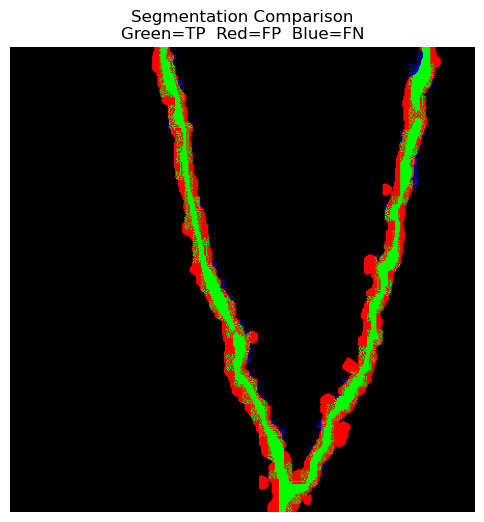

In [221]:
gt = cv2.imread(r"D:\CPV ti len tt\masks\CRACK500_20160330_163725_641_721.jpg",0) > 0
 
pred = mask > 0

tp = pred & gt
fp = pred & (~gt)
fn = (~pred) & gt

vis = np.zeros((gt.shape[0], gt.shape[1],3))

vis[tp] = [0,1,0]   # green
vis[fp] = [1,0,0]   # red
vis[fn] = [0,0,1]   # blue

plt.figure(figsize=(6,8))
plt.imshow(vis)
plt.title("Segmentation Comparison\nGreen=TP  Red=FP  Blue=FN")
plt.axis("off")

In [ ]:
TP = np.sum(tp)
FP = np.sum(fp)
FN = np.sum(fn)
#IOU metric 

precision = TP / (TP + FP + 1e-8)
recall = TP / (TP + FN + 1e-8)
f1 = 2*precision*recall/(precision+recall+1e-8)
iou = TP/(TP+FP+FN+1e-8)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("IoU:", iou)

Precision: 0.4904752044722588
Recall: 0.9557191849899579
F1: 0.6482621739516105
IoU: 0.4795768588346006
